In [360]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from copy import deepcopy

np.random.seed(123)

Для начала сгенерируем данные, они буду повторять данные из dz1_1. Попробую добавить много шумных признаков в обучающую выборку, чтобы дать ей возможность переобучится (без этого она не будет переробучаться, проверял ). Шумные признаки - это просто рандомно сгенерированные признаки без привязки к y, т.е. по ним никак нельзя предсказать значение y

In [361]:
x = 2 * np.random.rand(100, 1)
y = 4.3 * x + 2 

scaler = StandardScaler()

y_noise = y + np.random.randn(100, 1)

X_learn, x_test,Y_learn, y_test = train_test_split(x,y_noise , test_size=0.2)
X_control, X_test,Y_control, Y_test  = train_test_split(x_test,y_test, test_size= 0.5)

X_noises = np.random.randn(80,100) # 100 шумных признаков
X_learn = np.hstack([X_learn, X_noises])
X_control =np.hstack([X_control, np.random.randn(len(X_control), 100)])
X_test = np.hstack([X_test, np.random.randn(len(X_test), 100)])

x_learn_original = X_learn.copy()

X_learn = scaler.fit_transform(X_learn)
X_control = scaler.transform(X_control)
X_test = scaler.transform(X_test)


Y_learn = Y_learn.ravel()
Y_control = Y_control.ravel()
Y_test = Y_test.ravel()




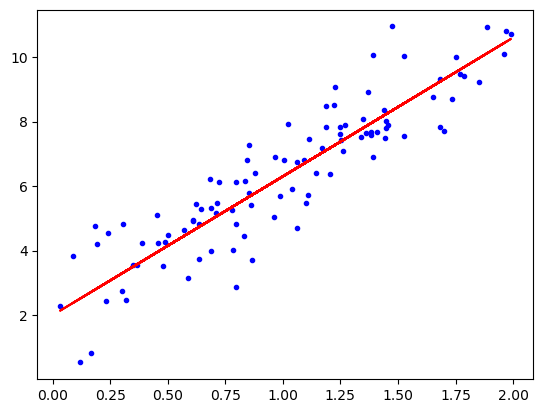

In [362]:
plt.plot(x, y_noise, "b.")
plt.plot(x, y, "r-")
plt.show()

In [363]:
SGD_reg = SGDRegressor(max_iter=1500, tol = None, penalty=None, eta0=0.05, random_state=42)
SGD_model = SGD_reg.fit(X_learn, Y_learn)

y_predict = SGD_model.predict(X_learn)
model_r2_learn = r2_score(Y_learn, y_predict )
model_MSE_learn = np.sqrt(mean_squared_error( Y_learn, y_predict))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learnin: ", model_r2_learn)



MSE on learning:  1.3711036379418887e-08
R2 on learnin:  1.0


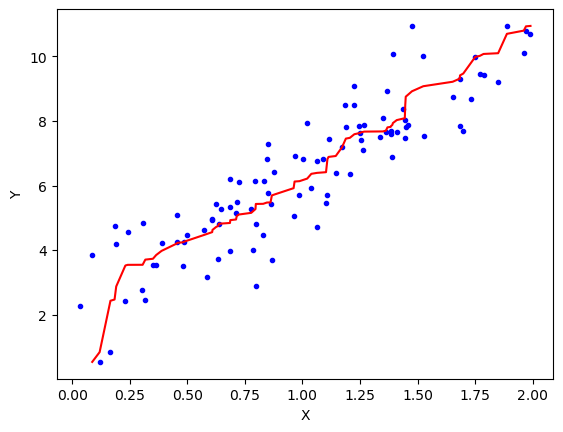

In [364]:
plt.plot(x,y_noise, "b.")
plt.plot(sorted(x_learn_original[:,0]), sorted(y_predict), "r-")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Очень похоже на переобучения и по метрикам и по графику . Посмотрим, что дадут тесты

In [365]:


y_pred_control = SGD_model.predict(X_control)

model_r2_control = r2_score(Y_control, y_pred_control )
model_MSE_control = np.sqrt(mean_squared_error(Y_control, y_pred_control ))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)



MSE on control:  1.3810936487871002
R2 on control:  0.4807934955225063


На лицо переробучение , попробую также избавиться от него с помощью разных методов. Начну с гребневой регресии

In [366]:
ridge_model = Ridge(alpha=1, random_state=42)
ridge_model.fit(X_learn, Y_learn)

y_predict = ridge_model.predict(X_learn)
model_r2_learn = r2_score(Y_learn, y_predict )
model_MSE_learn = np.sqrt(mean_squared_error(Y_learn, y_predict ))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learnin: ", model_r2_learn)

MSE on learning:  0.055396373415442214
R2 on learnin:  0.9994418152649609


In [367]:
y_pred_control = ridge_model.predict(X_control)

model_r2_control = r2_score(Y_control, y_pred_control )
model_MSE_control = np.sqrt(mean_squared_error( Y_control, y_pred_control))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)


MSE on control:  1.3006529077524904
R2 on control:  0.5395137139987174


Гребневая регрессия никак не помогла. Попробую применить регрессию Лассо

In [368]:
lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_learn, Y_learn)
y_predict = lasso_model.predict(X_learn)
model_r2_learn = r2_score(Y_learn, y_predict )
model_MSE_learn = np.sqrt(mean_squared_error(Y_learn, y_predict))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learnin: ", model_r2_learn)

MSE on learning:  1.1428029298544555
R2 on learnin:  0.7624483903624744


Тут мы можем видеть, что признаков переобучения нет, проверим тестами и графиком

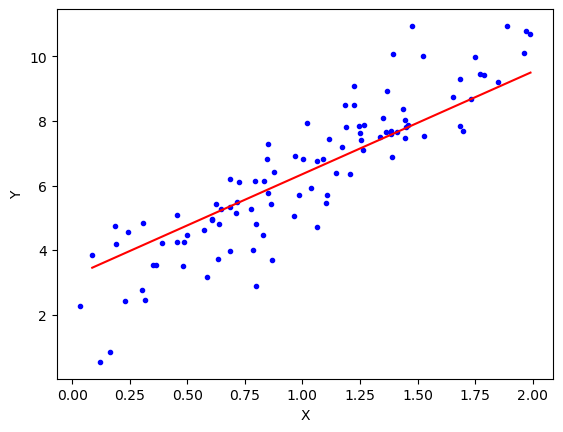

In [369]:
plt.plot(x,y_noise, "b.")
plt.plot(sorted(x_learn_original[:,0]), sorted(y_predict), "r-")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [371]:
y_pred_lasso_test = lasso_model.predict(X_test)

model_r2_control = r2_score( Y_test, y_pred_lasso_test)
model_MSE_control = np.sqrt(mean_squared_error(Y_test, y_pred_lasso_test))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)

MSE on control:  0.6869961017390424
R2 on control:  0.8718386917435323


Мне кажется, это успех  и нам удалось побороть переробучения. Проверю как работает метод эластичной сети

In [372]:
elastic_model = ElasticNet(alpha=0.5)
elastic_model.fit(X_learn, Y_learn)

y_predict = elastic_model.predict(X_learn)
model_r2_learn = r2_score( Y_learn, y_predict)
model_MSE_learn = np.sqrt(mean_squared_error(Y_learn, y_predict))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learnin: ", model_r2_learn)


MSE on learning:  1.1555601842730272
R2 on learnin:  0.7571151501234401


In [373]:
y_pred_control = elastic_model.predict(X_control)

model_r2_control = r2_score( Y_control, y_pred_control)
model_MSE_control = np.sqrt(mean_squared_error(Y_control, y_pred_control))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)


MSE on control:  1.0348420622700913
R2 on control:  0.7084976811043586


Далее попробую применить метод ранней остановки

In [374]:
sgd_reg = SGDRegressor(max_iter=1, tol = 0.0, warm_start=True, penalty=None, learning_rate="constant", eta0=0.0005, random_state=42)

minimun_val_eror = float("inf")
best_epoch = None
best_model = None

for epoch in range(1000):
    sgd_reg.fit(X_learn, Y_learn)
    y_val_predisct = sgd_reg.predict(X_control)
    val_error = mean_squared_error(Y_control, y_val_predisct)
    if val_error < minimun_val_eror:
        minimun_val_eror = val_error
        best_epoch = epoch
        best_model = deepcopy(sgd_reg)



/home/ivankorolev/anaconda3/envs/envForML/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ivankorolev/anaconda3/envs/envForML/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ivankorolev/anaconda3/envs/envForML/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ivankorolev/anaconda3/envs/envForML/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider i

In [375]:
y_predict = best_model.predict(X_learn)
model_r2_learn = r2_score( Y_learn, y_predict)
model_MSE_learn = np.sqrt(mean_squared_error(Y_learn, y_predict))

print("MSE on learning: ", model_MSE_learn)
print("R2 on learnin: ", model_r2_learn)

MSE on learning:  0.16941654790791863
R2 on learnin:  0.9947793215688432


In [376]:
y_pred_control = best_model.predict(X_control)

model_r2_control = r2_score( Y_control, y_pred_control)
model_MSE_control = np.sqrt(mean_squared_error(Y_control, y_pred_control))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)

MSE on control:  1.1963032867845331
R2 on control:  0.6104381135338945


как видно , ранняя остановка не сильно помогла. Посмотрев на все использованные методы, могу сказать, что лучше всего српавился метод Lasso и эластичной сети . проверю их обоих на результирущей выборке

In [378]:
y_pred_control_lasso = lasso_model.predict(X_control)

model_r2_control = r2_score( Y_control, y_pred_control_lasso)
model_MSE_control = np.sqrt(mean_squared_error(Y_control, y_pred_control_lasso))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)


MSE on control:  1.0068036130594047
R2 on control:  0.7240798616072854


In [379]:
y_pred_control_elastic = elastic_model.predict(X_control)
model_r2_control = r2_score( Y_control, y_pred_control_elastic)
model_MSE_control = np.sqrt(mean_squared_error(Y_control, y_pred_control_elastic))

print("MSE on control: ", model_MSE_control)
print("R2 on control: ", model_r2_control)

MSE on control:  1.0348420622700913
R2 on control:  0.7084976811043586


Хочу построить графики для наглядности решений

(100, 1)

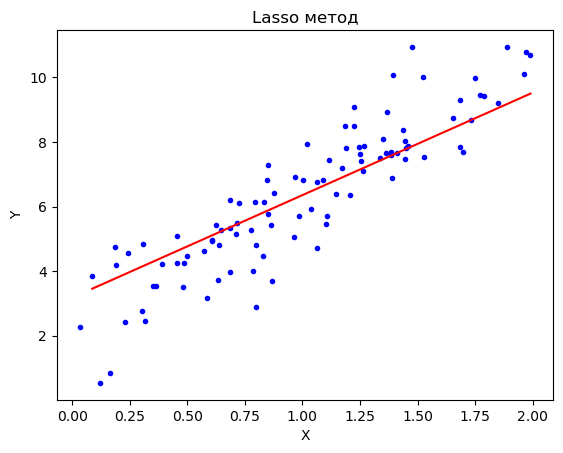

In [385]:
full_pred = lasso_model.predict(X_learn)

plt.plot(x,y_noise, "b.")
plt.plot(sorted(x_learn_original[:,0]), sorted(full_pred), "r-")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Lasso метод")
plt.show()

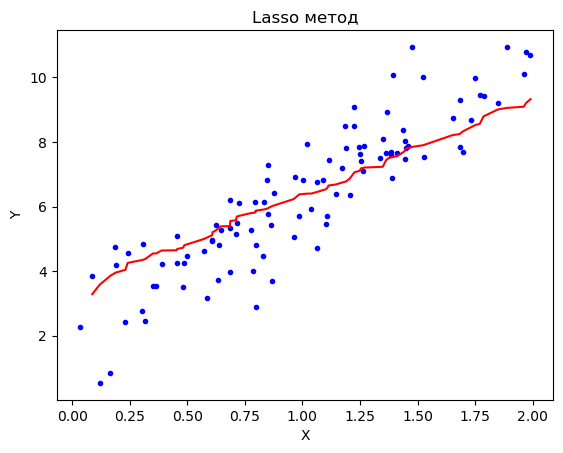

In [386]:
full_pred = elastic_model.predict(X_learn)

plt.plot(x,y_noise, "b.")
plt.plot(sorted(x_learn_original[:,0]), sorted(full_pred), "r-")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Lasso метод")
plt.show()